In [ ]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.utils import save_image
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

from src.utils.trainer import Trainer

In [22]:
# --------------------------------
# Trainer Setup
# --------------------------------

# ConvAutoencoder
trainer = Trainer(
    input_dir=Path("../data/resized"),
    compressed_dir=Path("../data/compressed"),
    checkpoints_dir=Path("../checkpoints"),
    base_channels=32,
    batch_size=4,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

trainer.load_dataset()

Device : cpu
Parameters : 2,389,859
Train 	| Val 	| Test : 
70 	| 15 	| 15


In [15]:
# --------------------------------
# Training
# --------------------------------

history = trainer.train(num_epochs=100)

Epoch   1/100  |  Train Loss: 0.325407  |  Val Loss:   0.312127


/home/enrico/Desktop/Projects/deep-image-restoration/src/training/trainer.py:254: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  original = original.to(self.device)


Epoch  10/100  |  Train Loss: 0.182394  |  Val Loss:   0.190894
Epoch  20/100  |  Train Loss: 0.168930  |  Val Loss:   0.183515
Epoch  30/100  |  Train Loss: 0.157235  |  Val Loss:   0.180197
Epoch  40/100  |  Train Loss: 0.137873  |  Val Loss:   0.181265
Epoch  50/100  |  Train Loss: 0.110346  |  Val Loss:   0.182704
Epoch  60/100  |  Train Loss: 0.091071  |  Val Loss:   0.181919
Epoch  70/100  |  Train Loss: 0.078652  |  Val Loss:   0.182139
Epoch  80/100  |  Train Loss: 0.074401  |  Val Loss:   0.190510
Epoch  90/100  |  Train Loss: 0.064025  |  Val Loss:   0.183010
Epoch 100/100  |  Train Loss: 0.064725  |  Val Loss:   0.180957

 Training complete. Best val loss: 0.177433
  Checkpoint saved: ../checkpoints/best_model_autoencoder.pth


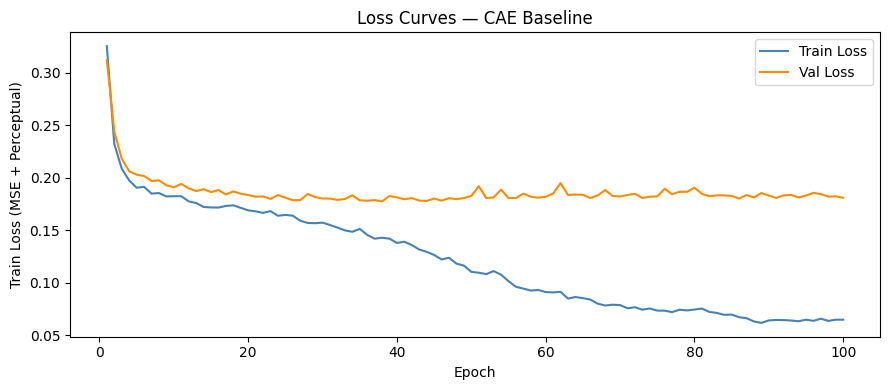

In [16]:
# --------------------------------
# Loss Curves
# --------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
plt.plot(epochs, history["val_loss"], label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE + Perceptual)")
plt.title("Loss Curves — CAE Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# --------------------------------
# Load Best Checkpoint
# --------------------------------

trainer.model.load_state_dict(
    torch.load(
        Path("../checkpoints/best_model_autoencoder.pth"), map_location=trainer.device
    )
)
trainer.model.eval()
print(" Best model loaded")

 Best model loaded


In [18]:
# --------------------------------
# Baseline PSNR — Compressed vs Original
# --------------------------------

psnr_baseline, ssim_baseline = [], []

for compressed, original in trainer.test_loader:
    for comp_t, orig_t in zip(compressed.numpy(), original.numpy()):
        comp_np = np.transpose(comp_t, (1, 2, 0))
        orig_np = np.transpose(orig_t, (1, 2, 0))
        psnr_baseline.append(calc_psnr(orig_np, comp_np, data_range=1.0))
        ssim_baseline.append(
            calc_ssim(orig_np, comp_np, data_range=1.0, channel_axis=2)
        )

psnr_base = np.mean(psnr_baseline)
ssim_base = np.mean(ssim_baseline)
print(f"Baseline  —  PSNR: {psnr_base:.2f} dB  |  SSIM: {ssim_base:.4f}")

Baseline  —  PSNR: 26.38 dB  |  SSIM: 0.7722


In [19]:
# --------------------------------
# PSNR / SSIM — Restored vs Original
# --------------------------------

psnr_list, ssim_list = [], []

with torch.no_grad():
    for compressed, original in trainer.test_loader:
        compressed = compressed.to(trainer.device)
        original = original.to(trainer.device)
        recon, _ = trainer.model(compressed)

        for out_t, orig_t in zip(recon.cpu().numpy(), original.cpu().numpy()):
            out_np = np.transpose(out_t, (1, 2, 0))
            orig_np = np.transpose(orig_t, (1, 2, 0))
            psnr_list.append(calc_psnr(orig_np, out_np, data_range=1.0))
            ssim_list.append(calc_ssim(orig_np, out_np, data_range=1.0, channel_axis=2))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"{'─' * 50}")
print(f"  PSNR baseline (compressed) : {psnr_base:.2f} dB")
print(
    f"  PSNR restored              : {psnr_mean:.2f} dB  ({psnr_mean - psnr_base:+.2f})"
)
print(f"  SSIM baseline (compressed) : {ssim_base:.4f}")
print(f"  SSIM restored              : {ssim_mean:.4f}  ({ssim_mean - ssim_base:+.4f})")
print(f"{'─' * 50}")

──────────────────────────────────────────────────
  PSNR baseline (compressed) : 26.38 dB
  PSNR restored              : 24.23 dB  (-2.15)
  SSIM baseline (compressed) : 0.7722
  SSIM restored              : 0.7058  (-0.0664)
──────────────────────────────────────────────────
